## **Figure-3**

In [1]:
import pandas as pd
import polars as pl
import sys 
from collections import defaultdict
from functools import reduce
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import seaborn as sns

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014')

condition = dict(orig='Initial', refined='Reconstructed', tl='Transfer-Learn')

In [4]:
def formatDf(rslt):
    avg_jaccard = defaultdict(dict)
    for lib, v in rslt.items():
        for cond, vv in v.items():
            avg_jaccard[lib][cond] = avg_jaccard_index(vv)

    avg_jaccard = pd.DataFrame(avg_jaccard).reset_index(names='Condition').melt(id_vars='Condition', var_name='Library', value_name='Jaccard Index')

    numIds = defaultdict(dict)
    for lib, v in rslt.items():
        for cond, vv in v.items():
            numIds[lib][cond] = np.array([len(i) for i in vv.values()]).mean()
    numIds = pd.DataFrame(numIds).reset_index(names='Condition').melt(id_vars='Condition', var_name='Library', value_name='# IDs')

    full = pd.merge(numIds, avg_jaccard)
    
    # Assuming your DataFrame is named df
    # Create a copy to avoid modifying the original
    relative = full.copy()

    # Create a mapping of original values for each library
    original_values = {}
    for _, row in relative[relative['Condition'] == condition['orig']].iterrows():
        original_values[row['Library']] = {
            'IDs': row['# IDs'],
            'Jaccard': row['Jaccard Index']
        }

    # Calculate differences for non-Original conditions
    for idx, row in relative.iterrows():
        if row['Condition'] != condition['orig']:
            library = row['Library']
            relative.at[idx, '# IDs'] = row['# IDs'] - original_values[library]['IDs']
            relative.at[idx, 'Jaccard Index'] = row['Jaccard Index'] - original_values[library]['Jaccard']

    # Filter out Original rows if you only want the differences
    # If you want to keep Original rows with zeros (no difference), comment out this line
    relative = relative[relative['Condition'] != 'Original']

    return full, relative

---

---

## **Load Data**

#### **Load IDs Vs Reproducibility Data**

In [5]:
diann = { n:defaultdict(dict) for n in names.values() }
osw = { n:defaultdict(dict) for n in names.values() }

In [6]:
# Bruker data
diann[names['bruker']][condition['orig']]['1'] = getPrecursorSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['orig']]['2'] = getPrecursorSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['bruker']][condition['orig']]['3'] = getPrecursorSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['bruker']][condition['refined']]['1'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['refined']]['2'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['bruker']][condition['refined']]['3'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['bruker']][condition['tl']]['1'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['tl']]['2'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['bruker']][condition['tl']]['3'] = getPrecursorSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# Silico data
diann[names['silico']][condition['orig']]['1'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['orig']]['2'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['silico']][condition['orig']]['3'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['silico']][condition['refined']]['1'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['refined']]['2'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['silico']][condition['refined']]['3'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['silico']][condition['tl']]['1'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['tl']]['2'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['silico']][condition['tl']]['3'] = getPrecursorSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# exp data
diann[names['exp']][condition['orig']]['1'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['exp']][condition['orig']]['2'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['exp']][condition['orig']]['3'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['exp']][condition['refined']]['1'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined']]['2'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined']]['3'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv", infer_schema_length=1000)

diann[names['exp']][condition['tl']]['1'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['tl']]['2'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['tl']]['3'] = getPrecursorSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv", infer_schema_length=1000)


# Panhuman data
diann[names['panhuman']][condition['orig']]['1'] = getPrecursorSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['orig']]['2'] = getPrecursorSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['panhuman']][condition['orig']]['3'] = getPrecursorSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['panhuman']][condition['refined']]['1'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['refined']]['2'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['panhuman']][condition['refined']]['3'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['panhuman']][condition['tl']]['1'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['tl']]['2'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['panhuman']][condition['tl']]['3'] = getPrecursorSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2u

In [7]:
# Bruker data
osw[names['bruker']][condition['orig']]['1'] = getPrecursorSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['bruker']][condition['orig']]['2'] = getPrecursorSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['bruker']][condition['orig']]['3'] = getPrecursorSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['bruker']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['bruker']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['bruker']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['bruker']][condition['tl']]['1'] = getPrecursorSet_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['bruker']][condition['tl']]['2'] = getPrecursorSet_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['bruker']][condition['tl']]['3'] = getPrecursorSet_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

# Panhuman data
osw[names['panhuman']][condition['orig']]['1'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['orig']]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['orig']]['3'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

osw[names['panhuman']][condition['refined']]['1'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['refined']]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['refined']]['3'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

osw[names['panhuman']][condition['tl'] ]['1'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['tl'] ]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['tl'] ]['2'] = getPrecursorSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

# Experimental data
osw[names['exp']][condition['orig']]['1'] = getPrecursorSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['exp']][condition['orig']]['2'] = getPrecursorSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['exp']][condition['orig']]['3'] = getPrecursorSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['exp']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['exp']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['exp']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['exp']][condition['tl']]['1'] = getPrecursorSet_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['exp']][condition['tl']]['2'] = getPrecursorSet_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['exp']][condition['tl']]['3'] = getPrecursorSet_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")


# Silico data
osw[names['silico']][condition['orig']]['1'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['silico']][condition['orig']]['2'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['silico']][condition['orig']]['3'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

osw[names['silico']][condition['refined']]['1'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['silico']][condition['refined']]['2'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['silico']][condition['refined']]['3'] = getPrecursorSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['silico']][condition['tl'] ]['1'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['silico']][condition['tl'] ]['2'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['silico']][condition['tl'] ]['3'] = getPrecursorSet_oswpq("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Sl

#### **Format ID-Reproducibility Data**

In [8]:
osw_full, osw_relative = formatDf(osw)
diann_full, diann_relative = formatDf(diann)

### **Load Peptide Charactersitics (RT and IM)**

In [9]:
osw_char = defaultdict(dict)

# Bruker data
osw_char[names['bruker']][condition['orig']] = getPrecursorDf_Characteristics("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_char[names['bruker']][condition['refined']] = getPrecursorDf_Characteristics("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_char[names['bruker']][condition['tl']] = getPrecursorDf_Characteristics_oswpq("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet")


# Panhuman data
osw_char[names['panhuman']][condition['orig']] = getPrecursorDf_Characteristics_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet")
osw_char[names['panhuman']][condition['refined']] = getPrecursorDf_Characteristics_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet")
osw_char[names['panhuman']][condition['tl'] ] = getPrecursorDf_Characteristics_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet")

# Experimental data
osw_char[names['exp']][condition['orig']] = getPrecursorDf_Characteristics("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_char[names['exp']][condition['refined']] = getPrecursorDf_Characteristics("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_char[names['exp']][condition['tl']] = getPrecursorDf_Characteristics_oswpq("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet")


# Silico data
osw_char[names['silico']][condition['orig']] = getPrecursorDf_Characteristics_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet")
osw_char[names['silico']][condition['refined']] = getPrecursorDf_Characteristics("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw_char[names['silico']][condition['tl'] ] = getPrecursorDf_Characteristics_oswpq("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet")

../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet
../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet
../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021

In [10]:
tmp = {}
for k, v in osw_char.items():
    tmp[k] = pd.concat(v).reset_index(names=['Condition', 'i']).drop(columns='i')
    
osw_df = pd.concat(tmp).reset_index(names=['Library', 'i']).drop(columns='i')
    

#### **Load Peptide Characterisitics - Relative Fragment Ion Intensity (Precomputed)**

In [11]:
osw_frag_df = pd.read_csv("osw-df-frags.tsv", sep='\t')

In [12]:
def create_characteristics_boxplot(ax, data, y, ylabel, show_xticks, ylim=None, font_size_small=7, font_size_medium=9, font_size_large=11):
    sns.set_palette(["tab:blue", "tab:orange", "tab:grey"])
    sns.boxplot(data=data, x='Library', hue='Condition', y=y, showfliers=False, ax=ax, order=names.values(), legend=False)
    ax.set_ylabel(ylabel, fontsize=font_size_medium)
    ax.axhline(0, color='black')

    if not show_xticks:
        ax.set_xticks([])
        ax.set_xlabel("")
    else:
        ax.tick_params(axis='x', rotation=30)

        ax.set_xlabel("Library", fontsize=font_size_medium)
    
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    if ylim is not None:
        ax.set_ylim(ylim)


In [13]:
def createPlot_IDs_Reproduce(df, 
                             title, 
                             ax, 
                             show_legends=True,
                             show_xlabel=True,
                             font_size_small = 7,
                             font_size_medium = 9, 
                             font_size_large = 11,
                             font_size_title = 11,
                             point_size = 30,
                             edge_width=1.5):
    # Define colors for each library
    library_colors = {
        names['exp']: '#1f77b4',
        names['silico']: '#ff7f0e', 
        names['bruker']: '#2ca02c',
        names['panhuman']: '#d62728',
    }
    
    # Plot points
    for library in df['Library'].unique():
        lib_data = df[df['Library'] == library]
        original = lib_data[lib_data['Condition'] == condition['tl']]
        refined = lib_data[lib_data['Condition'] == condition['refined']]
        color = library_colors[library]
        
        # Plot original (hollow circles with border)
        short_name = library.replace(' Library', '')
        ax.scatter(original['# IDs'], original['Jaccard Index'], 
                  s=point_size, facecolors=color, linewidth=edge_width, label=short_name, marker='x')
        
        # Plot refined (filled circles)  
        ax.scatter(refined['# IDs'], refined['Jaccard Index'],
                  s=point_size, c=color, alpha=0.9)
        
        # Add arrow from original to refined
        arrow = FancyArrowPatch(
            (original['# IDs'].iloc[0], original['Jaccard Index'].iloc[0]),
            (refined['# IDs'].iloc[0], refined['Jaccard Index'].iloc[0]),
            arrowstyle='->', mutation_scale=10, shrinkA=5, shrinkB=2,
            color=color, alpha=1, linewidth=1
        )
        ax.add_patch(arrow)
    
    # Customize the plot
    if show_xlabel:
        ax.set_xlabel('Improvement in\nAverage # Peptide Precursors', fontsize=font_size_medium)
    else:
        ax.set_xlabel('')  # Remove x-axis label
        ax.tick_params(axis='x', labelbottom=False)  # Hide x-axis tick labels
    
    
    # Customize the plot
    ax.set_ylabel('Improvement in Jaccard Index', fontsize=font_size_medium)
    
    
    # Set axis limits with some padding
    x_min, x_max = df['# IDs'].min() - 2000, df['# IDs'].max() + 2000
    y_min, y_max = df['Jaccard Index'].min() - 0.01, df['Jaccard Index'].max() + 0.01
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # Format x-axis to show values in thousands (only if showing x-axis)
    #if show_xlabel:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    ax.tick_params(axis='y', which='major', labelsize=font_size_small)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')

    # Create legends only if requested
    if show_legends:
        # Create custom condition legend
        condition_legend_elements = [
            Line2D([0], [0], marker='x', color='w', markerfacecolor='none', 
               markeredgecolor='black', markersize=7, markeredgewidth=1.5, 
               label='Transfer Learn', linestyle='None'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                   markersize=10, alpha=1, label='Reconstructed', linestyle='None'),
        ]
        # Add library colors to legend
        library_legend_elements = []
        for library, color in library_colors.items():
            short_name = library.replace(' Library', '')
            if short_name != 'Direct':
                library_legend_elements.append(
                    Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                           markersize=8, alpha=1, label=short_name, 
                           linestyle='None')
                )
        legend1 = ax.legend(handles=condition_legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.4), 
                  fontsize=font_size_small)
        ax.add_artist(legend1)
        ax.legend(handles=library_legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.58), 
                  fontsize=font_size_small)
    
    ax.set_xlim(-10000, 50000)
    ax.set_ylim(-0.01, 0.2)
    ax.set_title(title)
    axvhline_color = 'darkgray'

    ax.axvline(0, color=axvhline_color, zorder=-100)
    ax.axhline(0, color=axvhline_color, zorder=-100)

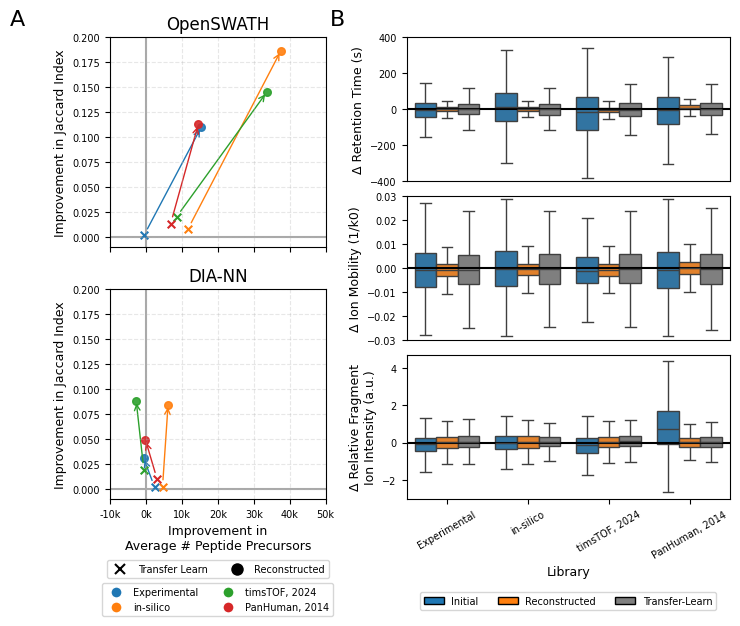

In [14]:
fig = plt.figure(figsize=(8, 6))

# Two columns side by side
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 6], wspace=0.3)

# --- Left column (2 stacked plots) ---
gs_left = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0, 0], hspace=0.2)


ax1 = fig.add_subplot(gs_left[0, 0])
ax2 = fig.add_subplot(gs_left[1, 0])

#createPlot_IDs_Reproduce(osw_relative, 'OpenSWATH', ax1, show_xlabel=False, show_legends=False)
createPlot_IDs_Reproduce(osw_relative, 'OpenSWATH', ax1, show_xlabel=False, show_legends=False) ### DUMMY DATA for now
createPlot_IDs_Reproduce(diann_relative, 'DIA-NN', ax2)

# --- Right column (3 stacked plots) ---
gs_right = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[0, 1], hspace=0.1)

ax3 = fig.add_subplot(gs_right[0, 0])
create_characteristics_boxplot(ax3, osw_df, 'FEATURE.DELTA_RT', 'Δ Retention Time (s)', show_xticks=False, ylim=(-400, 400))

ax4 = fig.add_subplot(gs_right[1, 0])
create_characteristics_boxplot(ax4, osw_df, 'FEATURE_MS2.DELTA_IM', 'Δ Ion Mobility (1/k0)', show_xticks=False, ylim=(-0.03, 0.03))

ax5 = fig.add_subplot(gs_right[2, 0])
create_characteristics_boxplot(ax5, osw_frag_df, 'residual', 'Δ Relative Fragment\nIon Intensity (a.u.)', show_xticks=True)

# add legend for plots 
handles = [Patch(facecolor=c, label=l, edgecolor='black') for c, l in zip(['tab:blue', 'tab:orange', 'tab:grey'], condition.values()) ]
ax5.legend(handles=handles, labels=condition.values(), ncols=3, loc='lower center', bbox_to_anchor=(0.5, -0.8), fontsize=7)

fig.text(0, 0.9, 'A', fontsize=16) 
fig.text(0.4, 0.9, 'B', fontsize=16) 
plt.savefig("figure3.png", dpi=300, bbox_inches='tight')


### **For Manuscript - Fold Change Decrease across libraries for reconstructed and transfer learn libraries**

In [15]:
osw_df[['Library', 'Condition', 'FEATURE.DELTA_RT']].groupby(['Library', 'Condition']).std()

FEATURE.DELTA_RT
Library        Condition                       
Experimental   Initial                69.042839
               Reconstructed          22.611924
               Transfer-Learn         48.878830
PanHuman, 2014 Initial               125.488184
               Reconstructed          18.306341
               Transfer-Learn         65.750015
in-silico      Initial               126.812164
               Reconstructed          20.125018
               Transfer-Learn         58.880006
timsTOF, 2024  Initial               178.594600
               Reconstructed          26.048975
               Transfer-Learn         64.313541

Compare Reconstructed to transfer learn. 

In [16]:
(48.87/22.61 + 58.88/20.12 + 81.89/1906 + 64.31/26.04) /4

1.9001251819251657

In [17]:
(69/22 + 126/20 + 130/19 + 178/26) /4

5.7811556864188445

In [18]:
(69/48 + 126/58 + 130/81 + 178/64) /4

1.9990255161770967